In [1]:
# Cell 1
from pynq import Overlay, allocate
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 2
# Load the overlay (Bitstream + Hardware Handoff)
# Ensure 'sobel_02.bit' and 'sobel_02.hwh' are in this folder
overlay = Overlay("sobel_02.bit")

# Helper to access the DMA engine
dma = overlay.axi_dma_0

print("Bitstream loaded successfully. Hardware is ready.")

Bitstream loaded successfully. Hardware is ready.


In [3]:
# Cell 3
def run_software_sobel(image_path):
    """
    Reads an image, resizes it to 256x256, and runs Sobel using CPU (OpenCV).
    """
    # 1. Read Image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Image {image_path} not found!")
    
    # 2. Resize to 256x256 (To match hardware constraint)
    img_resized = cv2.resize(img, (256, 256))
    
    # 3. Start Timer
    start = time.time()
    
    # 4. Perform Sobel (Software)
    # Calculate Gx and Gy
    gx = cv2.Sobel(img_resized, cv2.CV_16S, 1, 0, ksize=3)
    gy = cv2.Sobel(img_resized, cv2.CV_16S, 0, 1, ksize=3)
    
    # Calculate Gradient Magnitude (Approximating your Verilog logic: |Gx| + |Gy|)
    abs_gx = cv2.convertScaleAbs(gx)
    abs_gy = cv2.convertScaleAbs(gy)
    sobel_sw = cv2.addWeighted(abs_gx, 0.5, abs_gy, 0.5, 0)
    
    # 5. Stop Timer
    end = time.time()
    
    return img_resized, sobel_sw, (end - start)

In [4]:
# Cell 4
def run_hardware_sobel(img_input):
    """
    Takes a 256x256 numpy array, sends it to FPGA, and returns the result.
    """
    height, width = img_input.shape
    
    # 1. Allocate Contiguous Memory (CMA) for DMA
    # We must use 'allocate' because standard numpy arrays are not physically contiguous
    input_buffer = allocate(shape=(height, width), dtype=np.uint8)
    output_buffer = allocate(shape=(height, width), dtype=np.uint8)
    
    # 2. Copy data to the input buffer
    input_buffer[:] = img_input
    
    # 3. Start Timer
    start = time.time()
    
    # 4. Initiate DMA Transfer
    # Always start RECV before SEND to prevent stalling
    dma.recvchannel.transfer(output_buffer)
    dma.sendchannel.transfer(input_buffer)
    
    # 5. Wait for Hardware to Finish
    dma.sendchannel.wait() # Wait for send to complete
    dma.recvchannel.wait() # Wait for receive to complete
    
    # 6. Stop Timer
    end = time.time()
    
    # 7. Copy result out and free buffers
    result = output_buffer.copy()
    
    # Free the heavy memory buffers
    input_buffer.freebuffer()
    output_buffer.freebuffer()
    
    return result, (end - start)

--- Processing strawberry.jpeg ---
Software Time: 17.611 ms
Hardware Time: 1.646 ms
Speedup: 10.70x faster on FPGA

--- Processing rose_.jpeg ---
Software Time: 16.441 ms
Hardware Time: 1.626 ms
Speedup: 10.11x faster on FPGA



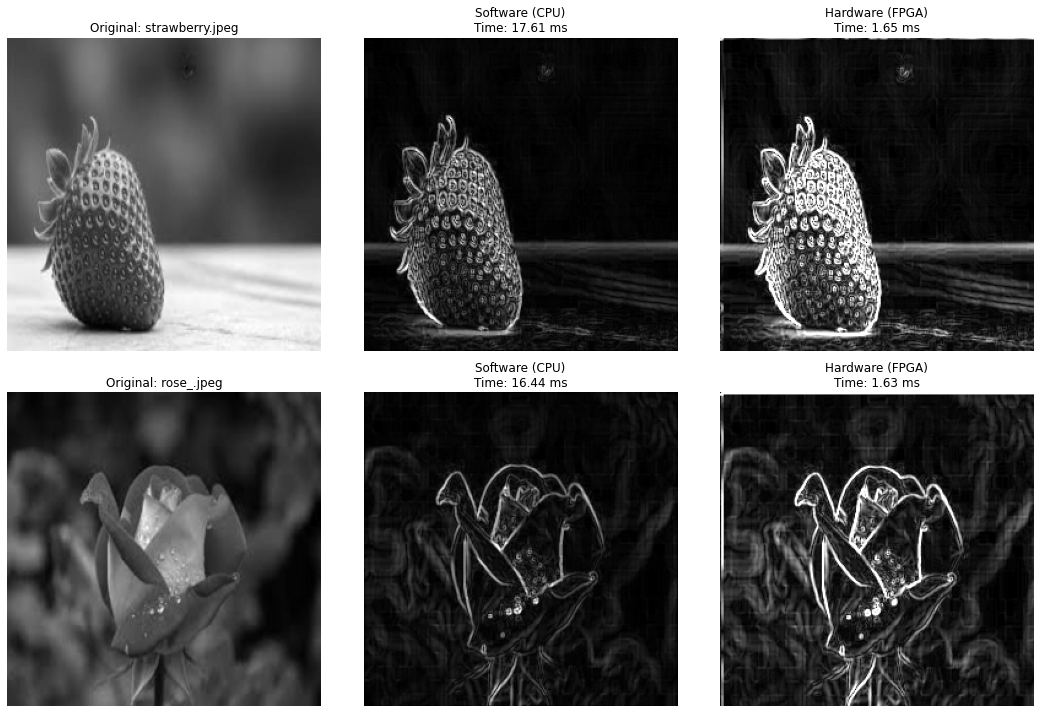

In [6]:
# Cell 5
# List of images to process
image_files = ["strawberry.jpeg", "rose_.jpeg"]

# Set up the plot
fig, axes = plt.subplots(len(image_files), 3, figsize=(15, 10))

for i, filename in enumerate(image_files):
    print(f"--- Processing {filename} ---")
    
    try:
        # A. Run Software Version (CPU)
        original_img, sw_result, sw_time_sec = run_software_sobel(filename)
        sw_time_ms = sw_time_sec * 1000  # Convert to ms
        print(f"Software Time: {sw_time_ms:.3f} ms")
        
        # B. Run Hardware Version (FPGA)
        # We pass the same resized image used in SW to ensure fair comparison
        hw_result, hw_time_sec = run_hardware_sobel(original_img)
        hw_time_ms = hw_time_sec * 1000  # Convert to ms
        print(f"Hardware Time: {hw_time_ms:.3f} ms")
        
        # C. Calculate Speedup
        speedup = sw_time_sec / hw_time_sec
        print(f"Speedup: {speedup:.2f}x faster on FPGA\n")
        
        # D. Plotting
        # Column 1: Original
        axes[i, 0].imshow(original_img, cmap='gray')
        axes[i, 0].set_title(f"Original: {filename}")
        axes[i, 0].axis('off')
        
        # Column 2: Software Result
        axes[i, 1].imshow(sw_result, cmap='gray')
        axes[i, 1].set_title(f"Software (CPU)\nTime: {sw_time_ms:.2f} ms")
        axes[i, 1].axis('off')
        
        # Column 3: Hardware Result
        axes[i, 2].imshow(hw_result, cmap='gray')
        axes[i, 2].set_title(f"Hardware (FPGA)\nTime: {hw_time_ms:.2f} ms")
        axes[i, 2].axis('off')
        
    except Exception as e:
        print(f"Error processing {filename}: {e}")

plt.tight_layout()
plt.show()

Looking for images in: ../pest_expts_/test_images/

--- Processing class_101_69498.jpg ---
--- Processing class_24_17085.jpg ---
--- Processing class_51_36793.jpg ---
--- Processing class_67_44628.jpg ---
--- Processing class_70_52369.jpg ---


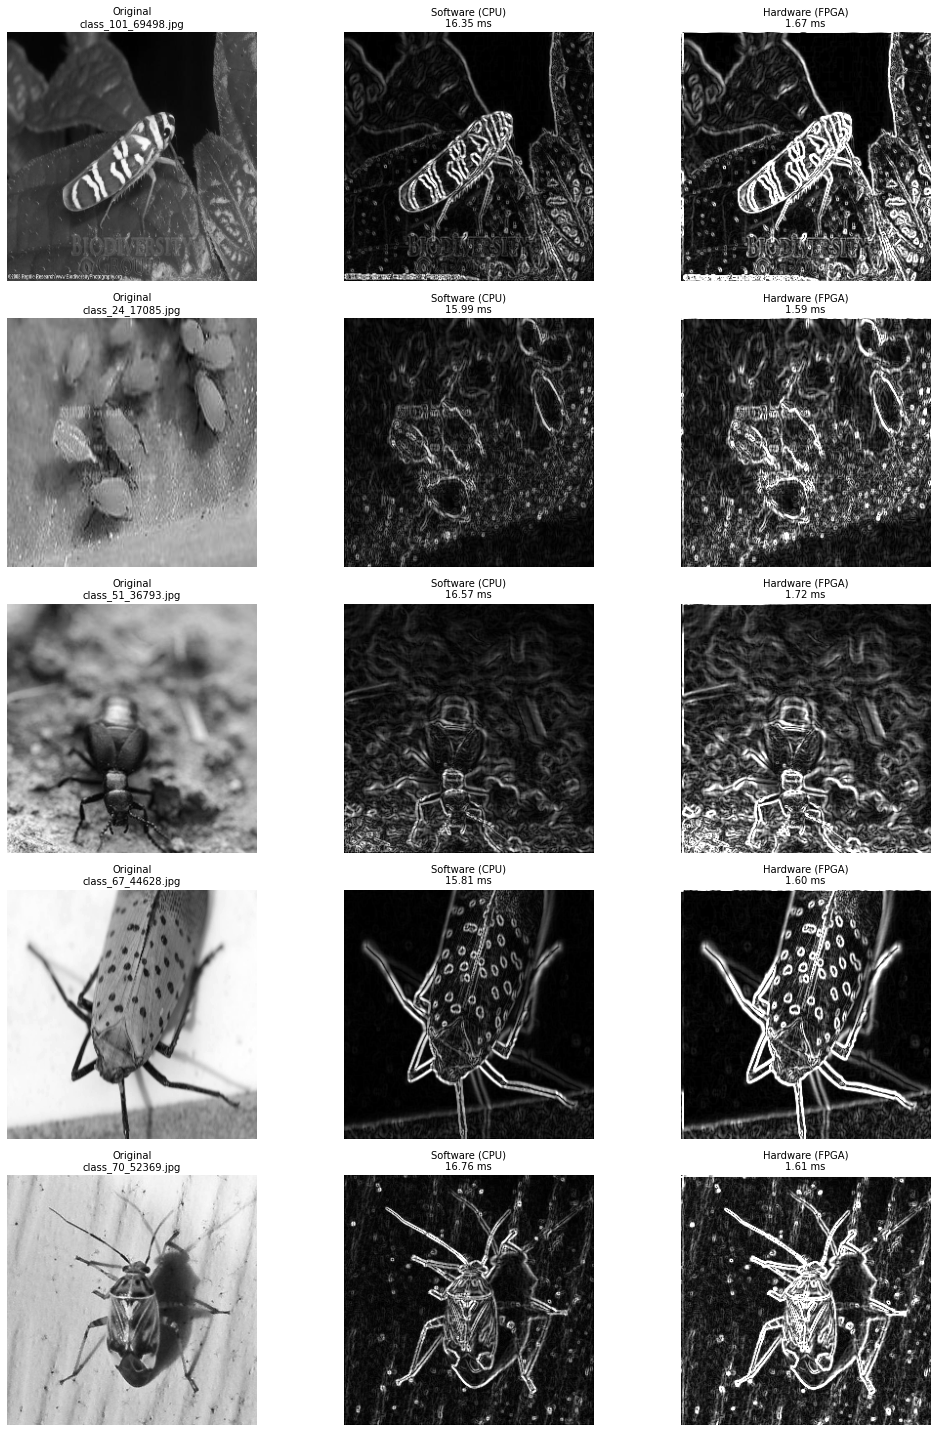

In [7]:
# Cell 6
import os

# 1. Define the Relative Path
# "../" moves up from 'test_project_folder' to the root
# then we go down into 'pest_expts_/test_images/'
folder_path = "../pest_expts_/test_images/"

# 2. List the specific files from your screenshot
# I transcribed these exactly from your image
image_names = [
    "class_101_69498.jpg",
    "class_24_17085.jpg",
    "class_51_36793.jpg",
    "class_67_44628.jpg",
    "class_70_52369.jpg"
]

# 3. Setup Visualization (5 rows, 3 columns)
fig, axes = plt.subplots(len(image_names), 3, figsize=(15, 20))

# List to store data for the table later
results_table = []

print(f"Looking for images in: {folder_path}\n")

for i, filename in enumerate(image_names):
    full_path = os.path.join(folder_path, filename)
    
    # Check if file exists to avoid crashes
    if not os.path.exists(full_path):
        print(f"Error: Could not find {full_path}")
        continue

    print(f"--- Processing {filename} ---")
    
    try:
        # A. Run Software (CPU)
        # Note: We pass the 'full_path' so cv2 can find it
        original_img, sw_result, sw_time_sec = run_software_sobel(full_path)
        sw_time_ms = sw_time_sec * 1000
        
        # B. Run Hardware (FPGA)
        # We pass the loaded 'original_img' (numpy array)
        hw_result, hw_time_sec = run_hardware_sobel(original_img)
        hw_time_ms = hw_time_sec * 1000
        
        # C. Calculate Speedup
        speedup = sw_time_sec / hw_time_sec
        
        # Save data for table
        results_table.append([filename, sw_time_ms, hw_time_ms, speedup])
        
        # D. Plotting
        # Row i, Column 0: Original
        axes[i, 0].imshow(original_img, cmap='gray')
        axes[i, 0].set_title(f"Original\n{filename}", fontsize=10)
        axes[i, 0].axis('off')
        
        # Row i, Column 1: Software
        axes[i, 1].imshow(sw_result, cmap='gray')
        axes[i, 1].set_title(f"Software (CPU)\n{sw_time_ms:.2f} ms", fontsize=10)
        axes[i, 1].axis('off')
        
        # Row i, Column 2: Hardware
        axes[i, 2].imshow(hw_result, cmap='gray')
        axes[i, 2].set_title(f"Hardware (FPGA)\n{hw_time_ms:.2f} ms", fontsize=10)
        axes[i, 2].axis('off')
        
    except Exception as e:
        print(f"Failed to process {filename}: {e}")

plt.tight_layout()
plt.show()

In [8]:
# Cell 6
# Print a professional summary table

print(f"{'Image Name':<25} | {'SW Time (ms)':<15} | {'HW Time (ms)':<15} | {'Speedup':<10}")
print("-" * 75)

total_sw = 0
total_hw = 0

for row in results_table:
    name, sw, hw, spd = row
    total_sw += sw
    total_hw += hw
    print(f"{name:<25} | {sw:<15.3f} | {hw:<15.3f} | {spd:<10.2f}x")

print("-" * 75)
avg_speedup = total_sw / total_hw if total_hw > 0 else 0
print(f"{'AVERAGE':<25} | {total_sw/len(results_table):<15.3f} | {total_hw/len(results_table):<15.3f} | {avg_speedup:<10.2f}x")

Image Name                | SW Time (ms)    | HW Time (ms)    | Speedup   
---------------------------------------------------------------------------
class_101_69498.jpg       | 16.352          | 1.671           | 9.79      x
class_24_17085.jpg        | 15.986          | 1.594           | 10.03     x
class_51_36793.jpg        | 16.568          | 1.715           | 9.66      x
class_67_44628.jpg        | 15.805          | 1.599           | 9.89      x
class_70_52369.jpg        | 16.763          | 1.608           | 10.42     x
---------------------------------------------------------------------------
AVERAGE                   | 16.295          | 1.637           | 9.95      x
